In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy
from torchdiffeq import odeint as torchodeint
from tqdm import tqdm
import torch.nn as nn
from kan import KAN as efficientkan #from efficient kan
from RBF_KAN_multiquadratic import RBFKAN
from ChebyKANLayer import ChebyKANLayer


In [20]:
def plotter(t, tf_learn, pred, soln_arr, epoch, loss_train, loss_test):
    #callback plotter during training, plots current solution
    plt.close('all')
    plt.figure()
    plt.plot(t, soln_arr[:, 0].detach(), color='g')
    plt.plot(t, soln_arr[:, 1].detach(), color='b')
    plt.plot(t, pred[:, 0].detach(), linestyle='dashed', color='g')
    plt.plot(t, pred[:, 1].detach(), linestyle='dashed', color='b')

    plt.legend(['x_data', 'y_data', 'x_KAN-ODE', 'y_KAN-ODE'])
    plt.ylabel('concentration')
    plt.xlabel('time')
    plt.vlines(tf_learn, 0, 5)
    #plt.savefig("plots/pred_prey/training_updates/train_epoch_"+str(epoch) +".png", dpi=200, facecolor="w", edgecolor="w", orientation="portrait")
    
    plt.figure()
    plt.semilogy(torch.Tensor(loss_train), label='train')
    plt.semilogy(torch.Tensor(loss_test), label='test')
    plt.legend()
    plt.xlabel('epoch')
    plt.ylabel('loss')
    #plt.savefig("plots/pred_prey/loss.png", dpi=200, facecolor="w", edgecolor="w", orientation="portrait")
    plt.show()
    

In [29]:
def calDeriv(t, X):
    dXdt=model(X)
    return dXdt

def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

def duffing_deriv(X, t, alpha, beta, delta, gamma, omega):
    x = X[0]
    y = X[1]
    y_dot = gamma*np.cos(omega*t) - beta*x**3 - alpha*x - delta*y
    return [y, y_dot]

In [30]:
class DuffingChebyKAN(nn.Module):
    def __init__(self):
        super(DuffingChebyKAN, self).__init__()
        self.chebykan1 = ChebyKANLayer(2, 10, 4)
        self.ln1 = nn.LayerNorm(10) # To avoid gradient vanishing caused by tanh
        self.chebykan2 = ChebyKANLayer(10, 2, 4)
        #self.ln2 = nn.LayerNorm(10)
        #self.chebykan3 = ChebyKANLayer(10, 2, 4)

    def forward(self, x):
        x = self.chebykan1(x)
        x = self.ln1(x)
        x = self.chebykan2(x)
        #x = self.ln2(x)
        #x = self.chebykan3(x)
        return x

In [48]:
def main_varyingICS(X, duffingParameters, model):
    tf=30
    tf_learn=14
    N_t_train=2800
    N_t=int((N_t_train*tf/tf_learn))
    lr=2e-3
    num_epochs=1501
    plot_freq=500
    is_restart=False
    
    
    ##coefficients from https://arxiv.org/pdf/2012.07244
    alpha = -1
    beta = 1
    delta = 0
    gamma = 0
    omega = 1.2
    
    x0 = 1
    y0 = 0.5


    X0=np.array(X)
    t=np.linspace(0, tf, N_t)
    soln_arr=scipy.integrate.odeint(duffing_deriv, X0, t, args=(*duffingParameters,))
    
    X0=torch.unsqueeze((torch.Tensor(np.transpose(X0))), 0)
    X0.requires_grad=True
    soln_arr=torch.Tensor(soln_arr)
    soln_arr.requires_grad=True
    soln_arr_train=soln_arr[:N_t_train, :]
    t=torch.Tensor(t)
    t_learn=torch.tensor(np.linspace(0, tf_learn, N_t_train))

    loss_list_train=[]
    loss_list_test=[]
    #initialize ADAM optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    
    loss_min=1e10 #arbitrarily large to overwrite later
    opt_plot_counter=0
    
    epoch_cutoff=10 #start at smaller lr to initialize, then bump it up
    
    #p1=model.layers[0].spline_weight
    #p2=model.layers[0].base_weight
    #p3=model.layers[1].spline_weight
    #p4=model.layers[1].base_weight
    for epoch in tqdm(range(num_epochs)):
        #if epoch==epoch_cutoffs[2]:
        #    model = kan.KAN(width=[2,3,2], grid=grids[1], k=3).initialize_from_another_model(model, X0_train)
        model.train()
        optimizer.zero_grad()
    
        #pred=torchodeint(calDeriv, X0, t_learn, adjoint_params=[p1, p2, p3, p4])
        pred=torchodeint(calDeriv, X0, t_learn)
        loss_train=torch.mean(torch.square(pred[:, 0, :]-soln_arr_train))
        loss_train.retain_grad()
        loss_train.backward()
        optimizer.step()
        loss_list_train.append(loss_train.detach().cpu())
        #pred_test=torchodeint(calDeriv, X0, t, adjoint_params=[])
        model.eval()
        pred_test=torchodeint(calDeriv, X0, t)
        loss_list_test.append(torch.mean(torch.square(pred_test[N_t_train:,0, :]-soln_arr[N_t_train:, :])).detach().cpu())

        if epoch % plot_freq == 0:
            plotter(t, tf_learn, pred_test[:, 0, :], soln_arr, epoch, loss_list_train, loss_list_test)


  0%|                                                                                         | 0/1501 [00:00<?, ?it/s]

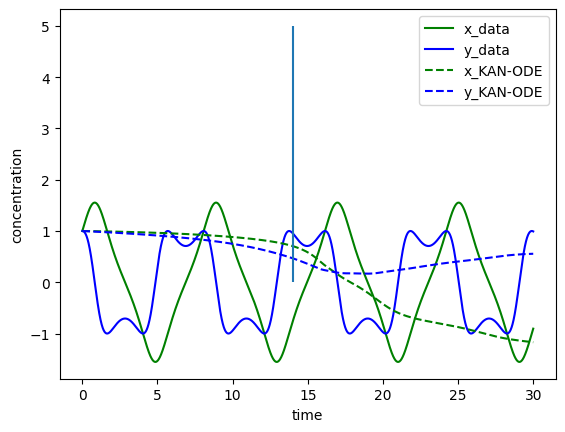

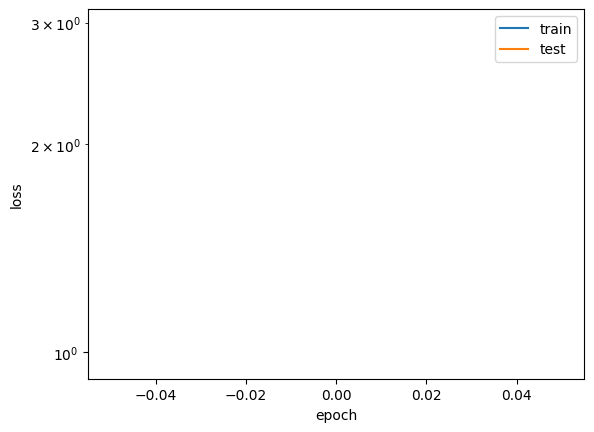

 33%|██████████████████████████▎                                                    | 500/1501 [16:17<30:54,  1.85s/it]

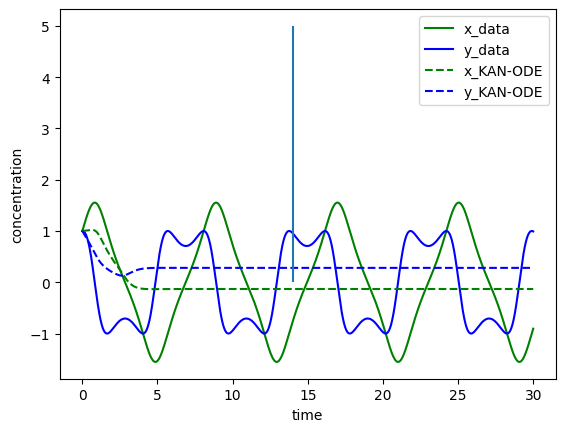

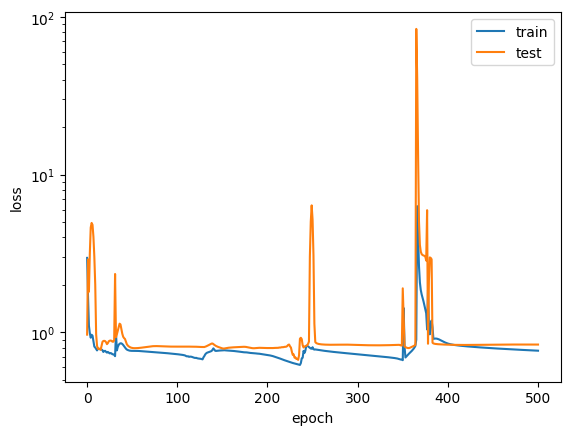

 67%|███████████████████████████████████████████████████▉                          | 1000/1501 [33:35<20:29,  2.45s/it]

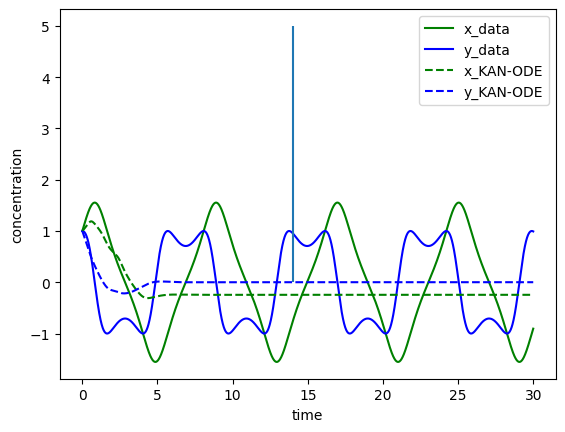

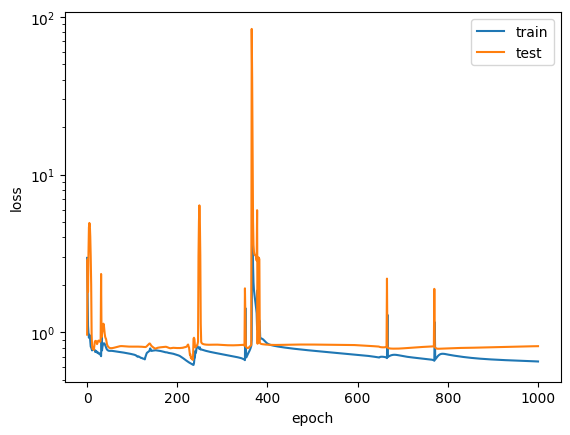

100%|█████████████████████████████████████████████████████████████████████████████▉| 1500/1501 [58:40<00:03,  3.37s/it]

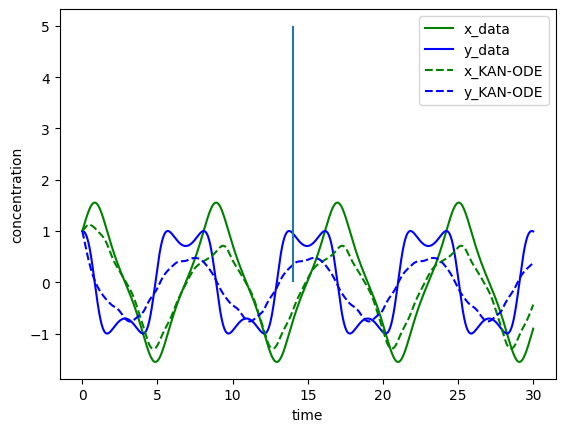

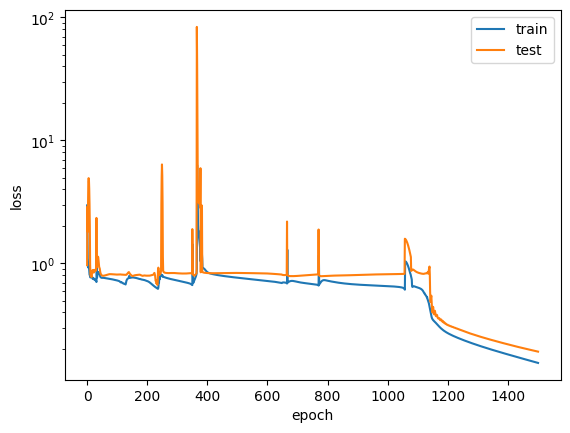

  0%|                                                                                         | 0/1501 [00:00<?, ?it/s]

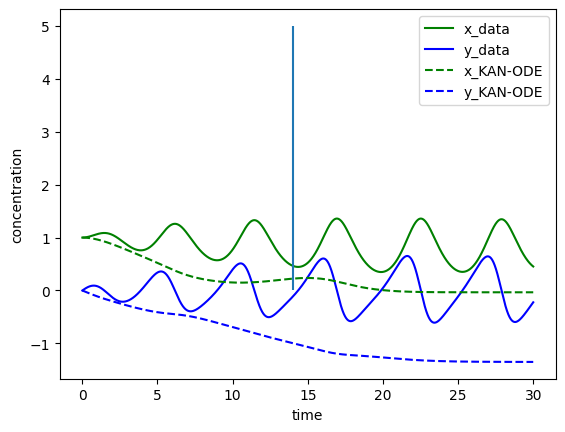

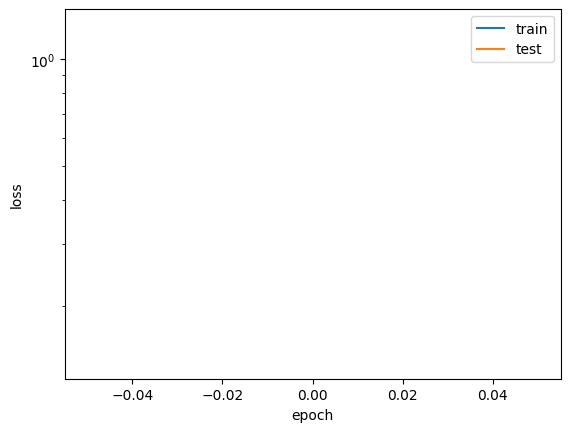

 33%|██████████████████████████▎                                                    | 500/1501 [13:29<26:25,  1.58s/it]

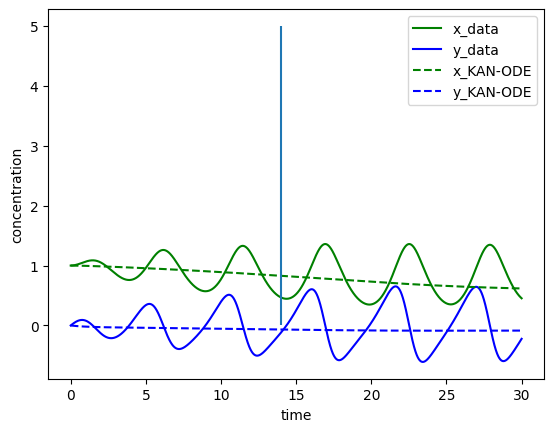

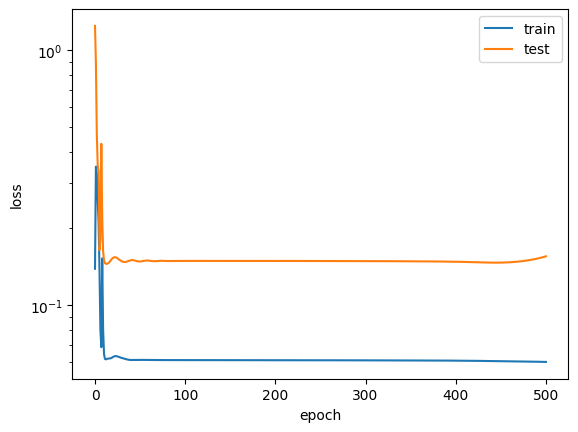

 67%|███████████████████████████████████████████████████▉                          | 1000/1501 [26:36<12:29,  1.50s/it]

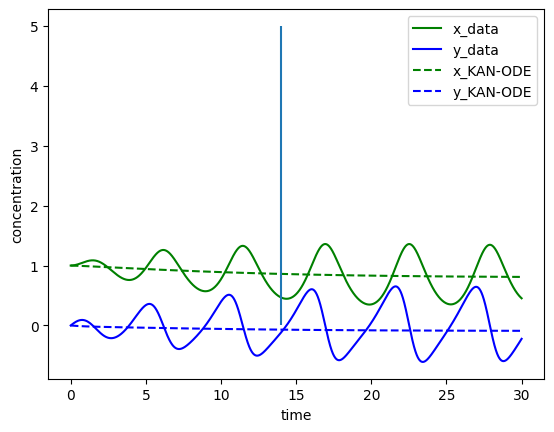

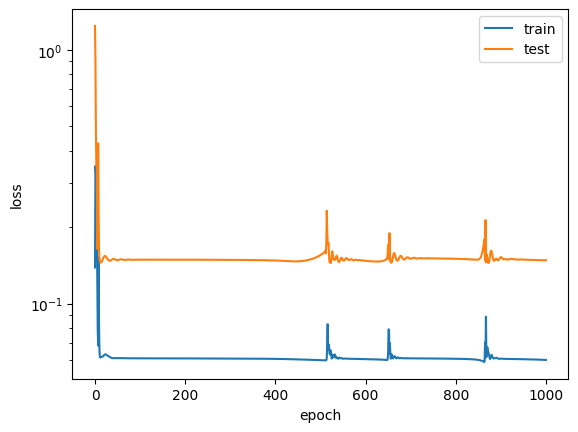

100%|█████████████████████████████████████████████████████████████████████████████▉| 1500/1501 [40:56<00:01,  1.71s/it]

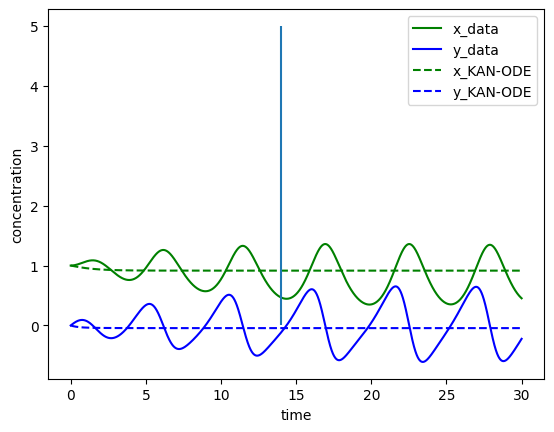

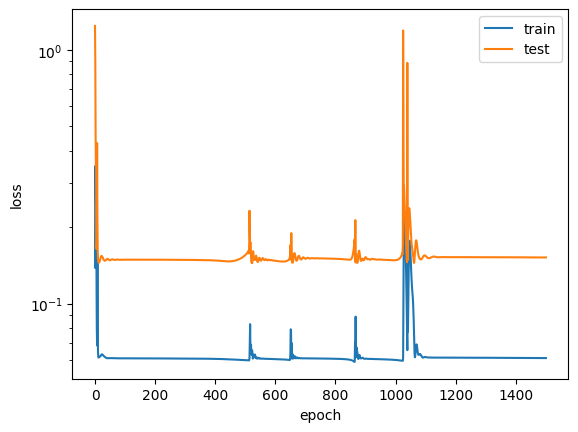

100%|██████████████████████████████████████████████████████████████████████████████| 1501/1501 [40:58<00:00,  1.64s/it]


In [49]:
# testing different parameters and initial conditions for the duffing oscilator equation, gets stuck in local minima most of the time

X = [[1, 1], [1,0]]

parameters = [[-1, 1, 0, 0 ,1.2], [-1, 1, 0.3, 0.2 ,1.2]]

for X, parameters in zip(X, parameters):
    model = DuffingChebyKAN()
    main_varyingICS(X, parameters, model)